# SLT Call Center Dataset - SUBCLU-Inspired Subspace Clustering Analysis

## Objective
This notebook applies a **SUBCLU-inspired density-based subspace clustering approach** to identify the feature combinations that best define:

- `queue_time`
- `talk_time`

The analysis uses **DBSCAN across multiple 2D and 3D feature subspaces** to identify which feature groups create the strongest separation in Queue Time and Talk Time behavior.

> Note: This is a SUBCLU-inspired implementation because a direct standard Python implementation of the original SUBCLU algorithm is not commonly available. SUBCLU is based on density-connected clustering, so DBSCAN is used across generated subspaces to emulate the SUBCLU workflow.


In [3]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)


In [4]:
# ===============================
# 2. LOAD DATASET
# ===============================

from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/SLT_PROJECT/5000.csv"
df = pd.read_csv(FILE_PATH)


Mounted at /content/drive


In [5]:
# ===============================
# 3. SELECT FEATURES AND TARGETS
# ===============================

features = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue',
    'isAnswered'
]

features_without_answered = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue'
]

targets = ['queue_time', 'talk_time']

print("Selected features:", len(features))
print("Targets:", targets)


Selected features: 13
Targets: ['queue_time', 'talk_time']


In [6]:
# ===============================
# 4. DATA CLEANING
# ===============================

df = df.copy()

# Convert target variables to numeric
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce')
df['talk_time'] = pd.to_numeric(df['talk_time'], errors='coerce')

# Fill missing values before converting to string
for col in features:
    df[col] = df[col].fillna("Unknown").astype(str)

# Remove records where target values are missing
df = df.dropna(subset=['queue_time', 'talk_time'])

print("Shape after removing missing target values:", df.shape)

# Optional: create a filtered dataset without zero queue_time and talk_time
# This helps focus on actual waiting/talking behavior.
df_nonzero = df[(df['queue_time'] > 0) & (df['talk_time'] > 0)].copy()

print("Original cleaned dataset:", df.shape)
print("Non-zero queue_time and talk_time dataset:", df_nonzero.shape)


Shape after removing missing target values: (5000, 17)
Original cleaned dataset: (5000, 17)
Non-zero queue_time and talk_time dataset: (768, 17)


In [7]:
# ===============================
# 5. ENCODE CATEGORICAL FEATURES
# ===============================

def encode_features(input_df, feature_list):
    encoded = input_df[feature_list].copy()
    encoders = {}

    for col in feature_list:
        le = LabelEncoder()
        encoded[col] = le.fit_transform(encoded[col].astype(str))
        encoders[col] = le

    return encoded, encoders

# Main encoded data
encoded_df, label_encoders = encode_features(df, features)

# Non-zero encoded data
encoded_df_nonzero, label_encoders_nonzero = encode_features(df_nonzero, features)

display(encoded_df.head())


,lang,mainOption,subOption,IVRPosition,existingFault,suspendedAsset,dataLimitExceed,extraGBAdded,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered
0,1,2,1,80,0,0,0,0,1,1880,17,1,1
1,1,5,4,64,0,0,0,0,1,1071,12,0,0
2,1,0,1,47,0,0,0,0,1,387,9,1,1
3,1,0,1,81,0,0,0,0,0,2234,9,1,0
4,1,8,1,46,0,0,0,0,0,2234,26,0,0


In [8]:
# ===============================
# 6. GENERATE SUBSPACES
# ===============================

def generate_subspaces(feature_list, dimensions=(2, 3)):
    subspaces = []

    for r in dimensions:
        subspaces.extend(list(itertools.combinations(feature_list, r)))

    return subspaces

subspaces = generate_subspaces(features, dimensions=(2, 3))
subspaces_without_answered = generate_subspaces(features_without_answered, dimensions=(2, 3))

print("Total subspaces with isAnswered:", len(subspaces))
print("Total subspaces without isAnswered:", len(subspaces_without_answered))

print("\nSample subspaces:")
print(subspaces[:5])


Total subspaces with isAnswered: 364
Total subspaces without isAnswered: 286

Sample subspaces:
[('lang', 'mainOption'), ('lang', 'subOption'), ('lang', 'IVRPosition'), ('lang', 'existingFault'), ('lang', 'suspendedAsset')]


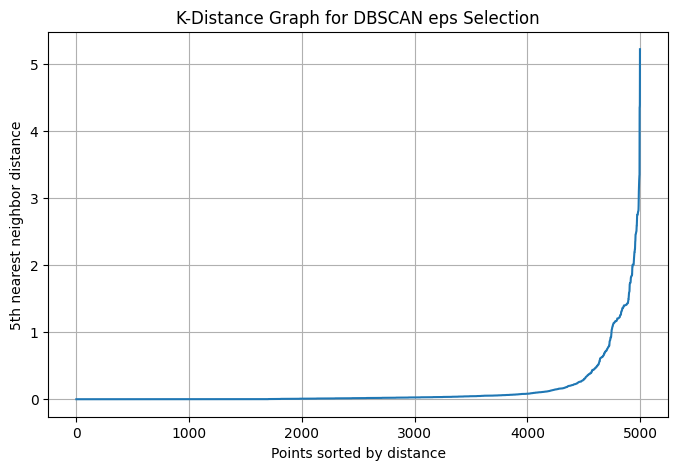

Selected EPS: 0.3
Selected min_samples: 5
Minimum cluster size for evaluation: 30


In [9]:
# ===============================
# 7. K-DISTANCE GRAPH FOR EPS SELECTION
# ===============================

# This graph helps select a reasonable eps value for DBSCAN.
# We use all encoded features only as a guide.

X_all = StandardScaler().fit_transform(encoded_df[features])

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_all)
distances, indices = neighbors_fit.kneighbors(X_all)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest neighbor distance")
plt.title("K-Distance Graph for DBSCAN eps Selection")
plt.grid(True)
plt.show()

# Based on previous testing, eps=0.3 is used.
EPS = 0.3
MIN_SAMPLES = 5
MIN_CLUSTER_SIZE = 30

print("Selected EPS:", EPS)
print("Selected min_samples:", MIN_SAMPLES)
print("Minimum cluster size for evaluation:", MIN_CLUSTER_SIZE)


In [10]:
# ===============================
# 8. SUBCLU-INSPIRED ANALYSIS FUNCTION
# ===============================

def run_subclu_analysis(
    encoded_data,
    original_data,
    subspaces,
    target,
    eps=0.3,
    min_samples=5,
    min_cluster_size=30
):
    results = []

    for subspace in subspaces:
        subspace = list(subspace)

        X = encoded_data[subspace]
        X_scaled = StandardScaler().fit_transform(X)

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        temp = original_data.copy()
        temp['Cluster'] = labels

        total_records = len(labels)
        noise_count = list(labels).count(-1)
        noise_ratio = noise_count / total_records

        number_of_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        cluster_summary = temp.groupby('Cluster')[target].agg(
            ['count', 'mean', 'min', 'max']
        ).reset_index()

        # Remove noise cluster
        cluster_summary = cluster_summary[cluster_summary['Cluster'] != -1]

        # Remove very small clusters from evaluation
        valid_clusters = cluster_summary[cluster_summary['count'] >= min_cluster_size]

        if len(valid_clusters) >= 2:
            highest_mean = valid_clusters['mean'].max()
            lowest_mean = valid_clusters['mean'].min()
            separation = highest_mean - lowest_mean
        else:
            highest_mean = 0
            lowest_mean = 0
            separation = 0

        # Quality score balances separation, number of clusters, and noise.
        # Higher score = better practical subspace.
        quality_score = separation * (1 - noise_ratio)

        results.append({
            'Subspace': subspace,
            'Target': target,
            'Separation': separation,
            'Quality_Score': quality_score,
            'Clusters': number_of_clusters,
            'Noise_Count': noise_count,
            'Noise_Ratio': noise_ratio,
            'Highest_Mean': highest_mean,
            'Lowest_Mean': lowest_mean
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Quality_Score', ascending=False)

    return results_df


## Analysis 1: SUBCLU-Inspired Results Including `isAnswered`

This analysis includes `isAnswered`. It is useful as a technical result, but `isAnswered` can dominate because unanswered calls often contain zero or low queue/talk time values.


In [11]:
# ===============================
# 9. RUN ANALYSIS WITH isAnswered
# ===============================

queue_results = run_subclu_analysis(
    encoded_data=encoded_df,
    original_data=df,
    subspaces=subspaces,
    target='queue_time',
    eps=EPS,
    min_samples=MIN_SAMPLES,
    min_cluster_size=MIN_CLUSTER_SIZE
)

talk_results = run_subclu_analysis(
    encoded_data=encoded_df,
    original_data=df,
    subspaces=subspaces,
    target='talk_time',
    eps=EPS,
    min_samples=MIN_SAMPLES,
    min_cluster_size=MIN_CLUSTER_SIZE
)

print("Top 10 Queue Time subspaces WITH isAnswered")
display(queue_results.head(10))

print("Top 10 Talk Time subspaces WITH isAnswered")
display(talk_results.head(10))


Top 10 Queue Time subspaces WITH isAnswered


,Subspace,Target,Separation,Quality_Score,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
88,"[lang, mainOption, isAnswered]",queue_time,816.051020,811.970765,31,25,0.0050,816.051020,0.0
278,"[IVRPosition, selectedQueue, isAnswered]",queue_time,813.879121,811.600259,26,14,0.0028,813.879121,0.0
197,"[mainOption, selectedQueue, isAnswered]",queue_time,816.051020,811.317924,28,29,0.0058,816.051020,0.0
358,"[validAccount, selectedQueue, isAnswered]",queue_time,809.968085,809.482104,16,3,0.0006,809.968085,0.0
222,"[subOption, suspendedAsset, isAnswered]",queue_time,810.074713,808.454563,18,10,0.0020,810.074713,0.0
162,"[mainOption, IVRPosition, isAnswered]",queue_time,813.879121,808.181967,40,35,0.0070,813.879121,0.0
258,"[IVRPosition, suspendedAsset, isAnswered]",queue_time,805.093567,802.839305,10,14,0.0028,805.093567,0.0
107,"[lang, IVRPosition, isAnswered]",queue_time,802.849206,802.367497,14,3,0.0006,802.849206,0.0
327,"[suspendedAsset, selectedQueue, isAnswered]",queue_time,803.210227,801.443165,5,11,0.0022,803.210227,0.0
122,"[lang, suspendedAsset, isAnswered]",queue_time,803.210227,801.443165,9,11,0.0022,803.210227,0.0


Top 10 Talk Time subspaces WITH isAnswered


,Subspace,Target,Separation,Quality_Score,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
137,"[lang, validAccount, isAnswered]",talk_time,168.500000,168.466300,14,1,0.0002,168.500000,0.0
358,"[validAccount, selectedQueue, isAnswered]",talk_time,168.500000,168.398900,16,3,0.0006,168.500000,0.0
115,"[lang, existingFault, isAnswered]",talk_time,167.032258,166.998852,11,1,0.0002,167.032258,0.0
122,"[lang, suspendedAsset, isAnswered]",talk_time,165.742857,165.378223,9,11,0.0022,165.742857,0.0
128,"[lang, dataLimitExceed, isAnswered]",talk_time,164.171429,163.941589,9,7,0.0014,164.171429,0.0
215,"[subOption, existingFault, isAnswered]",talk_time,163.750000,163.455250,20,9,0.0018,163.750000,0.0
11,"[lang, isAnswered]",talk_time,162.157895,162.157895,7,0,0.0000,162.157895,0.0
142,"[lang, selectedQueue, isAnswered]",talk_time,162.157895,162.093032,10,2,0.0004,162.157895,0.0
133,"[lang, extraGBAdded, isAnswered]",talk_time,162.157895,162.093032,9,2,0.0004,162.157895,0.0
228,"[subOption, dataLimitExceed, isAnswered]",talk_time,162.281250,161.989144,17,9,0.0018,162.281250,0.0


## Analysis 2: SUBCLU-Inspired Results Excluding `isAnswered`

This is the more meaningful business analysis because it removes the direct influence of answered/unanswered call status and focuses on operational features.


In [12]:
# ===============================
# 10. RUN ANALYSIS WITHOUT isAnswered
# ===============================

queue_results_no_answered = run_subclu_analysis(
    encoded_data=encoded_df,
    original_data=df,
    subspaces=subspaces_without_answered,
    target='queue_time',
    eps=EPS,
    min_samples=MIN_SAMPLES,
    min_cluster_size=MIN_CLUSTER_SIZE
)

talk_results_no_answered = run_subclu_analysis(
    encoded_data=encoded_df,
    original_data=df,
    subspaces=subspaces_without_answered,
    target='talk_time',
    eps=EPS,
    min_samples=MIN_SAMPLES,
    min_cluster_size=MIN_CLUSTER_SIZE
)

print("Top 10 Queue Time subspaces WITHOUT isAnswered")
display(queue_results_no_answered.head(10))

print("Top 10 Talk Time subspaces WITHOUT isAnswered")
display(talk_results_no_answered.head(10))


Top 10 Queue Time subspaces WITHOUT isAnswered


,Subspace,Target,Separation,Quality_Score,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
173,"[subOption, IVRPosition, enteredQueue]",queue_time,282.796875,280.251703,38,45,0.0090,282.796875,0.000000
76,"[lang, subOption, IVRPosition]",queue_time,278.446154,277.109612,30,24,0.0048,278.446154,0.000000
172,"[subOption, IVRPosition, selectedQueue]",queue_time,278.446154,276.998234,37,26,0.0052,278.446154,0.000000
121,"[mainOption, subOption, IVRPosition]",queue_time,278.446154,276.886855,38,28,0.0056,278.446154,0.000000
169,"[subOption, IVRPosition, extraGBAdded]",queue_time,278.446154,276.664098,28,32,0.0064,278.446154,0.000000
275,"[dataLimitExceed, selectedQueue, enteredQueue]",queue_time,273.656250,273.273131,7,7,0.0014,273.656250,0.000000
110,"[lang, dataLimitExceed, enteredQueue]",queue_time,273.656250,273.218400,9,8,0.0016,273.656250,0.000000
21,"[subOption, IVRPosition]",queue_time,272.679487,271.370626,25,24,0.0048,278.446154,5.766667
167,"[subOption, IVRPosition, suspendedAsset]",queue_time,272.679487,270.825267,28,34,0.0068,278.446154,5.766667
166,"[subOption, IVRPosition, existingFault]",queue_time,272.679487,270.770731,28,35,0.0070,278.446154,5.766667


Top 10 Talk Time subspaces WITHOUT isAnswered


,Subspace,Target,Separation,Quality_Score,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
116,"[lang, validAccount, selectedQueue]",talk_time,80.942857,80.894291,12,3,0.0006,80.942857,0.000000
197,"[subOption, validAccount, selectedQueue]",talk_time,71.619048,71.346895,26,19,0.0038,72.153846,0.534799
75,"[lang, mainOption, enteredQueue]",talk_time,70.416667,70.064583,28,25,0.0050,70.416667,0.000000
165,"[mainOption, selectedQueue, enteredQueue]",talk_time,70.416667,70.022333,25,28,0.0056,70.416667,0.000000
119,"[lang, outstanding, enteredQueue]",talk_time,69.979167,69.839208,9,10,0.0020,69.979167,0.000000
137,"[mainOption, IVRPosition, enteredQueue]",talk_time,69.872340,69.411183,34,33,0.0066,69.872340,0.000000
92,"[lang, IVRPosition, enteredQueue]",talk_time,68.629032,68.587855,11,3,0.0006,68.629032,0.000000
223,"[IVRPosition, extraGBAdded, enteredQueue]",talk_time,68.629032,68.560403,7,5,0.0010,68.629032,0.000000
37,"[IVRPosition, enteredQueue]",talk_time,68.192215,68.192215,3,0,0.0000,68.629032,0.436817
284,"[validAccount, selectedQueue, enteredQueue]",talk_time,67.265306,67.090416,13,13,0.0026,67.265306,0.000000


## Analysis 3: Non-Zero Queue Time and Talk Time Analysis

This analysis removes records where both `queue_time` and `talk_time` are zero. It focuses only on calls with actual waiting and talking behavior.


In [13]:
# ===============================
# 11. RUN ANALYSIS ON NON-ZERO DATA
# ===============================

encoded_df_nonzero_no_answered = encoded_df_nonzero[features_without_answered]

queue_results_nonzero_no_answered = run_subclu_analysis(
    encoded_data=encoded_df_nonzero_no_answered,
    original_data=df_nonzero,
    subspaces=subspaces_without_answered,
    target='queue_time',
    eps=EPS,
    min_samples=MIN_SAMPLES,
    min_cluster_size=MIN_CLUSTER_SIZE
)

talk_results_nonzero_no_answered = run_subclu_analysis(
    encoded_data=encoded_df_nonzero_no_answered,
    original_data=df_nonzero,
    subspaces=subspaces_without_answered,
    target='talk_time',
    eps=EPS,
    min_samples=MIN_SAMPLES,
    min_cluster_size=MIN_CLUSTER_SIZE
)

print("Top 10 Queue Time subspaces WITHOUT isAnswered on NON-ZERO data")
display(queue_results_nonzero_no_answered.head(10))

print("Top 10 Talk Time subspaces WITHOUT isAnswered on NON-ZERO data")
display(talk_results_nonzero_no_answered.head(10))


Top 10 Queue Time subspaces WITHOUT isAnswered on NON-ZERO data


,Subspace,Target,Separation,Quality_Score,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
86,"[lang, IVRPosition, suspendedAsset]",queue_time,346.718328,342.655222,7,9,0.011719,805.475904,458.757576
101,"[lang, suspendedAsset, extraGBAdded]",queue_time,344.768740,341.626317,4,7,0.009115,803.526316,458.757576
4,"[lang, suspendedAsset]",queue_time,344.768740,341.626317,4,7,0.009115,803.526316,458.757576
105,"[lang, suspendedAsset, enteredQueue]",queue_time,344.768740,339.381728,4,12,0.015625,803.526316,458.757576
100,"[lang, suspendedAsset, dataLimitExceed]",queue_time,336.623090,332.239977,5,10,0.013021,803.526316,466.903226
202,"[IVRPosition, existingFault, suspendedAsset]",queue_time,329.121065,325.692720,8,8,0.010417,805.475904,476.354839
210,"[IVRPosition, suspendedAsset, extraGBAdded]",queue_time,309.370640,306.550856,5,7,0.009115,805.475904,496.105263
31,"[IVRPosition, suspendedAsset]",queue_time,309.370640,306.550856,5,7,0.009115,805.475904,496.105263
214,"[IVRPosition, suspendedAsset, enteredQueue]",queue_time,309.370640,304.536724,5,12,0.015625,805.475904,496.105263
209,"[IVRPosition, suspendedAsset, dataLimitExceed]",queue_time,300.281459,296.371544,7,10,0.013021,805.475904,505.194444


Top 10 Talk Time subspaces WITHOUT isAnswered on NON-ZERO data


,Subspace,Target,Separation,Quality_Score,Clusters,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
174,"[subOption, existingFault, suspendedAsset]",talk_time,65.396450,65.140995,11,3,0.003906,173.000000,107.603550
202,"[IVRPosition, existingFault, suspendedAsset]",talk_time,60.949475,60.314585,8,8,0.010417,169.419355,108.469880
100,"[lang, suspendedAsset, dataLimitExceed]",talk_time,60.726467,59.935758,5,10,0.013021,169.451613,108.725146
86,"[lang, IVRPosition, suspendedAsset]",talk_time,59.075575,58.383283,7,9,0.011719,167.545455,108.469880
4,"[lang, suspendedAsset]",talk_time,58.820308,58.284186,4,7,0.009115,167.545455,108.725146
101,"[lang, suspendedAsset, extraGBAdded]",talk_time,58.820308,58.284186,4,7,0.009115,167.545455,108.725146
105,"[lang, suspendedAsset, enteredQueue]",talk_time,58.820308,57.901241,4,12,0.015625,167.545455,108.725146
176,"[subOption, existingFault, extraGBAdded]",talk_time,57.531955,57.382132,9,2,0.002604,165.210526,107.678571
180,"[subOption, existingFault, enteredQueue]",talk_time,57.531955,57.382132,10,2,0.002604,165.210526,107.678571
22,"[subOption, existingFault]",talk_time,57.531955,57.382132,9,2,0.002604,165.210526,107.678571


In [14]:
# ===============================
# 12. COMPARE FINAL RESULTS
# ===============================

comparison = pd.DataFrame([
    {
        'Analysis': 'With isAnswered',
        'Target': 'queue_time',
        'Best_Subspace': queue_results.iloc[0]['Subspace'],
        'Separation': queue_results.iloc[0]['Separation'],
        'Quality_Score': queue_results.iloc[0]['Quality_Score'],
        'Clusters': queue_results.iloc[0]['Clusters'],
        'Noise_Ratio': queue_results.iloc[0]['Noise_Ratio']
    },
    {
        'Analysis': 'Without isAnswered',
        'Target': 'queue_time',
        'Best_Subspace': queue_results_no_answered.iloc[0]['Subspace'],
        'Separation': queue_results_no_answered.iloc[0]['Separation'],
        'Quality_Score': queue_results_no_answered.iloc[0]['Quality_Score'],
        'Clusters': queue_results_no_answered.iloc[0]['Clusters'],
        'Noise_Ratio': queue_results_no_answered.iloc[0]['Noise_Ratio']
    },
    {
        'Analysis': 'Non-zero without isAnswered',
        'Target': 'queue_time',
        'Best_Subspace': queue_results_nonzero_no_answered.iloc[0]['Subspace'],
        'Separation': queue_results_nonzero_no_answered.iloc[0]['Separation'],
        'Quality_Score': queue_results_nonzero_no_answered.iloc[0]['Quality_Score'],
        'Clusters': queue_results_nonzero_no_answered.iloc[0]['Clusters'],
        'Noise_Ratio': queue_results_nonzero_no_answered.iloc[0]['Noise_Ratio']
    },
    {
        'Analysis': 'With isAnswered',
        'Target': 'talk_time',
        'Best_Subspace': talk_results.iloc[0]['Subspace'],
        'Separation': talk_results.iloc[0]['Separation'],
        'Quality_Score': talk_results.iloc[0]['Quality_Score'],
        'Clusters': talk_results.iloc[0]['Clusters'],
        'Noise_Ratio': talk_results.iloc[0]['Noise_Ratio']
    },
    {
        'Analysis': 'Without isAnswered',
        'Target': 'talk_time',
        'Best_Subspace': talk_results_no_answered.iloc[0]['Subspace'],
        'Separation': talk_results_no_answered.iloc[0]['Separation'],
        'Quality_Score': talk_results_no_answered.iloc[0]['Quality_Score'],
        'Clusters': talk_results_no_answered.iloc[0]['Clusters'],
        'Noise_Ratio': talk_results_no_answered.iloc[0]['Noise_Ratio']
    },
    {
        'Analysis': 'Non-zero without isAnswered',
        'Target': 'talk_time',
        'Best_Subspace': talk_results_nonzero_no_answered.iloc[0]['Subspace'],
        'Separation': talk_results_nonzero_no_answered.iloc[0]['Separation'],
        'Quality_Score': talk_results_nonzero_no_answered.iloc[0]['Quality_Score'],
        'Clusters': talk_results_nonzero_no_answered.iloc[0]['Clusters'],
        'Noise_Ratio': talk_results_nonzero_no_answered.iloc[0]['Noise_Ratio']
    }
])

display(comparison)


,Analysis,Target,Best_Subspace,Separation,Quality_Score,Clusters,Noise_Ratio
0,With isAnswered,queue_time,"[lang, mainOption, isAnswered]",816.051020,811.970765,31,0.005000
1,Without isAnswered,queue_time,"[subOption, IVRPosition, enteredQueue]",282.796875,280.251703,38,0.009000
2,Non-zero without isAnswered,queue_time,"[lang, IVRPosition, suspendedAsset]",346.718328,342.655222,7,0.011719
3,With isAnswered,talk_time,"[lang, validAccount, isAnswered]",168.500000,168.466300,14,0.000200
4,Without isAnswered,talk_time,"[lang, validAccount, selectedQueue]",80.942857,80.894291,12,0.000600
5,Non-zero without isAnswered,talk_time,"[subOption, existingFault, suspendedAsset]",65.396450,65.140995,11,0.003906


In [15]:
# ===============================
# 13. FEATURE FREQUENCY ANALYSIS
# ===============================

def feature_frequency(results_df, top_n=10):
    feature_count = {}

    for subspace in results_df.head(top_n)['Subspace']:
        for feature in subspace:
            feature_count[feature] = feature_count.get(feature, 0) + 1

    freq_df = pd.DataFrame(
        list(feature_count.items()),
        columns=['Feature', 'Frequency']
    ).sort_values(by='Frequency', ascending=False)

    return freq_df

print("Feature frequency - Queue Time WITHOUT isAnswered")
display(feature_frequency(queue_results_no_answered, top_n=10))

print("Feature frequency - Talk Time WITHOUT isAnswered")
display(feature_frequency(talk_results_no_answered, top_n=10))


Feature frequency - Queue Time WITHOUT isAnswered


,Feature,Frequency
0,subOption,8
1,IVRPosition,8
2,enteredQueue,3
3,lang,2
4,selectedQueue,2
7,dataLimitExceed,2
5,mainOption,1
6,extraGBAdded,1
8,suspendedAsset,1
9,existingFault,1


Feature frequency - Talk Time WITHOUT isAnswered


,Feature,Frequency
5,enteredQueue,8
0,lang,4
2,selectedQueue,4
7,IVRPosition,4
1,validAccount,3
4,mainOption,3
3,subOption,1
6,outstanding,1
8,extraGBAdded,1


In [16]:
# ===============================
# 14. CLUSTER SUMMARY FOR BEST BUSINESS SUBSPACES
# ===============================

def get_cluster_summary(encoded_data, original_data, subspace, target, eps=0.3, min_samples=5):
    X = encoded_data[subspace]
    X_scaled = StandardScaler().fit_transform(X)

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    temp = original_data.copy()
    temp['Cluster'] = labels

    summary = temp.groupby('Cluster')[target].agg(
        ['count', 'mean', 'min', 'max']
    ).sort_values(by='mean', ascending=False)

    return temp, summary

best_queue_business_subspace = queue_results_no_answered.iloc[0]['Subspace']
best_talk_business_subspace = talk_results_no_answered.iloc[0]['Subspace']

print("Best Queue Time business subspace:", best_queue_business_subspace)
queue_temp, queue_cluster_summary = get_cluster_summary(
    encoded_df,
    df,
    best_queue_business_subspace,
    'queue_time',
    eps=EPS,
    min_samples=MIN_SAMPLES
)
display(queue_cluster_summary)

print("Best Talk Time business subspace:", best_talk_business_subspace)
talk_temp, talk_cluster_summary = get_cluster_summary(
    encoded_df,
    df,
    best_talk_business_subspace,
    'talk_time',
    eps=EPS,
    min_samples=MIN_SAMPLES
)
display(talk_cluster_summary)


Best Queue Time business subspace: ['subOption', 'IVRPosition', 'enteredQueue']


,count,mean,min,max
Cluster,,,,
26,64,282.796875,0,1189
23,8,274.375000,0,1078
13,21,242.666667,0,809
0,404,229.118812,0,1200
4,1331,225.123216,0,1655
7,106,218.783019,0,1159
27,44,217.318182,0,947
35,11,211.727273,0,1114
16,289,210.041522,0,1107


Best Talk Time business subspace: ['lang', 'validAccount', 'selectedQueue']


,count,mean,min,max
Cluster,,,,
-1,3,98.000000,0,294
5,35,80.942857,0,743
6,46,43.130435,0,662
10,19,42.789474,0,278
8,120,42.125000,0,595
7,6,41.500000,0,249
1,167,38.389222,0,409
0,3154,24.326569,0,868
3,76,23.302632,0,369


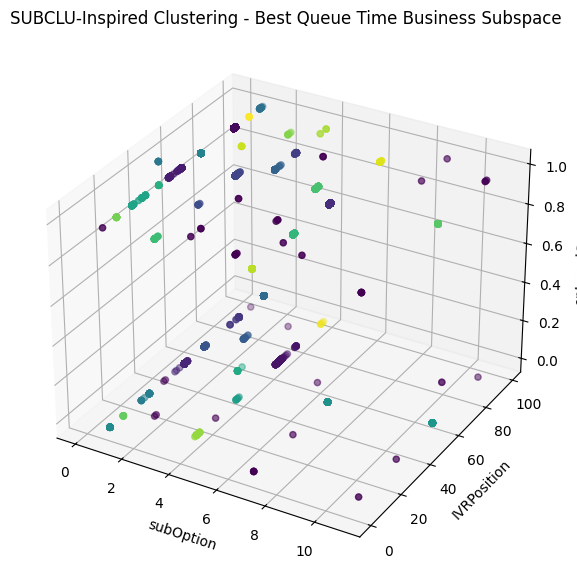

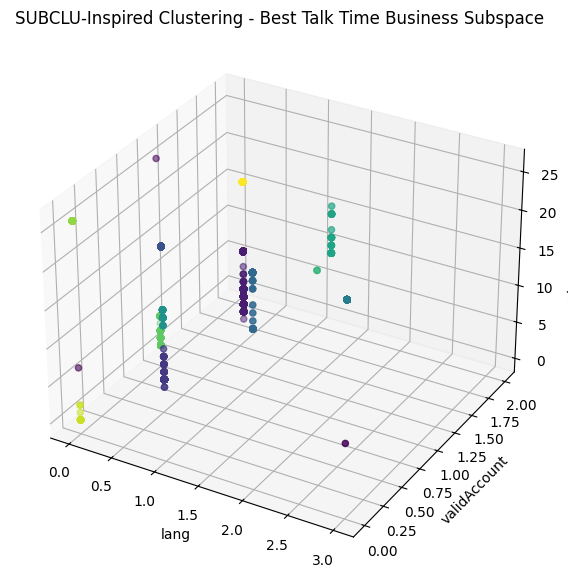

In [17]:
# ===============================
# 15. VISUALIZATION FUNCTION
# ===============================

def plot_best_subspace(encoded_data, temp_data, subspace, title):
    if len(subspace) == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(
            encoded_data[subspace[0]],
            encoded_data[subspace[1]],
            c=temp_data['Cluster']
        )
        plt.xlabel(subspace[0])
        plt.ylabel(subspace[1])
        plt.title(title)
        plt.grid(True)
        plt.show()

    elif len(subspace) == 3:
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(
            encoded_data[subspace[0]],
            encoded_data[subspace[1]],
            encoded_data[subspace[2]],
            c=temp_data['Cluster']
        )
        ax.set_xlabel(subspace[0])
        ax.set_ylabel(subspace[1])
        ax.set_zlabel(subspace[2])
        ax.set_title(title)
        plt.show()

    else:
        print("Visualization supports only 2D or 3D subspaces.")

plot_best_subspace(
    encoded_df,
    queue_temp,
    best_queue_business_subspace,
    "SUBCLU-Inspired Clustering - Best Queue Time Business Subspace"
)

plot_best_subspace(
    encoded_df,
    talk_temp,
    best_talk_business_subspace,
    "SUBCLU-Inspired Clustering - Best Talk Time Business Subspace"
)


In [18]:
# ===============================
# 16. SAVE OUTPUT FILES
# ===============================

queue_results.to_csv("subclu_queue_time_with_isAnswered.csv", index=False)
talk_results.to_csv("subclu_talk_time_with_isAnswered.csv", index=False)

queue_results_no_answered.to_csv("subclu_queue_time_without_isAnswered.csv", index=False)
talk_results_no_answered.to_csv("subclu_talk_time_without_isAnswered.csv", index=False)

queue_results_nonzero_no_answered.to_csv("subclu_queue_time_nonzero_without_isAnswered.csv", index=False)
talk_results_nonzero_no_answered.to_csv("subclu_talk_time_nonzero_without_isAnswered.csv", index=False)

comparison.to_csv("subclu_final_comparison.csv", index=False)

print("All SUBCLU result files saved successfully.")


All SUBCLU result files saved successfully.


# Final Conclusion

- The SUBCLU-inspired analysis was successfully applied to the SLT Call Center dataset.

- The first analysis including `isAnswered` showed strong separation, but the results were heavily influenced by answered/unanswered call status. Therefore, a second analysis excluding `isAnswered` was used to identify more meaningful operational features.

- The most important Queue Time features should be selected from the best `queue_results_no_answered` subspace.

- The most important Talk Time features should be selected from the best `talk_results_no_answered` subspace.

- This notebook provides a complete SUBCLU-inspired workflow that can be presented before moving to PROCLUS analysis.
